In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

### Wczytanie oraz analiza danych

In [2]:
data = pd.read_csv('paysim.csv')
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


**Opis zmiennych w zbiorze danych**

* **`step`**:\
    Mapuje jednostkę czasu, w tym przypadku 1 krok to 1 godzina. Cała symulacja obejmuje 744 kroki (co daje dokładnie 31 dni).

* **`type`**:\
    Rodzaj wykonywanej operacji: `CASH-IN` (wpłata gotówki), `CASH-OUT` (wypłata gotówki), `DEBIT` (obciążenie konta), `PAYMENT` (płatność) oraz `TRANSFER` (przelew).

* **`amount`**:\
    Kwota transakcji w lokalnej walucie.

* **`nameOrig`**:\
    Klient (identyfikator klienta), który zainicjował transakcję. W tym zbiorze danych identyfikatory nadawców zawsze zaczynają się od litery **C** (od *Customer* – klient indywidualny).

* **`oldbalanceOrg`**:\
    Początkowe saldo na koncie nadawcy tuż przed dokonaniem transakcji.

* **`newbalanceOrig`**:\
    Nowe saldo na koncie nadawcy po zrealizowaniu transakcji.

* **`nameDest`**:\
    Identyfikator docelowego odbiorcy transakcji. Identyfikatory te mogą zaczynać się od litery **C** (od *Customer* – docelowy klient indywidualny) lub od litery **M** (od *Merchant* – docelowy handlowiec/sklep detaliczny). Warto zaznaczyć, że konta typu "M" występują wyłącznie jako odbiorcy w transakcjach typu `PAYMENT`.

* **`oldbalanceDest`**:\
    Początkowe saldo na koncie odbiorcy przed transakcją. **Uwaga:** Te informacje nie są dostępne (są sztucznie wyzerowane) dla klientów, których identyfikator zaczyna się na literę "M" (od *Merchants* – Handlowcy/Sklepy).

* **`newbalanceDest`**:\
    Nowe saldo na koncie odbiorcy po zaksięgowaniu transakcji. **Uwaga:** Podobnie jak wyżej, brak tych informacji dla Handlowców (identyfikatory zaczynające się na "M").

* **`isFraud`**:\
    Flaga (zmienna docelowa) oznaczająca transakcje wykonane przez nieuczciwych klientów (oszustów) wewnątrz symulacji. W tym konkretnym zbiorze danych zachowanie oszustów polega na przejęciu kontroli nad kontem, a następnie próbie wyczyszczenia go ze środków poprzez przelew na inne konto (`TRANSFER`) i natychmiastową wypłatę gotówki z systemu (`CASH-OUT`).

* **`isFlaggedFraud`**:\
    Flaga biznesowa (reguła systemowa banku), która ma na celu kontrolowanie masowych przelewów między kontami i blokowanie nielegalnych prób. W tym zbiorze za "nielegalną" (podejrzaną) próbę uznaje się każdą pojedynczą transakcję na kwotę przekraczającą 200 000.

Istotne informacje dotyczące symulacji:
- Zasady dla klientów: Każdy klient w symulacji posiada profil określający dozwolone zachowanie, w tym limity transakcji i maksymalne saldo. Jeśli klient osiągnie swój dzienny limit, symulator teoretycznie nie powinien pozwolić mu na dalsze wypłaty.
- Definicje transakcji: Transakcja PAYMENT jest opisana jako płatność za towary lub usługi u kupców (merchants), co zgodnie z założeniami powinno zmniejszać saldo na koncie nadawcy i zwiększać na koncie odbiorcy.  
- Skąd się biorą salda: Początkowy stan konta klienta jest przypisywany podczas jego generowania, na podstawie danych statystycznych zaczerpniętych z pliku wejściowego o nazwie "Balance Container".  
- Zbiór PaySim jest generowany sztucznie na podstawie prawdziwych logów z afrykańskiego systemu płatności mobilnych.  
- Błędy symulatora: Symulator celowo gubi niektóre stany kont po operacjach wyciągnięcia gotówki (CASH_OUT), żeby naśladować błędy w prawdziwych systemach bankowych.

In [3]:
data.shape

(6362620, 11)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
data.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
data.describe().style.format("{:.4f}")

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000
mean,243.3972,179861.9035,833883.1041,855113.6686,1100701.6665,1224996.3982,0.0013,0.0000
std,142.3320,603858.2315,2888242.6730,2924048.5030,3399180.1130,3674128.9421,0.0359,0.0016
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,156.0000,13389.5700,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,239.0000,74871.9400,14208.0000,0.0000,132705.6650,214661.4400,0.0000,0.0000
75%,335.0000,208721.4775,107315.1750,144258.4100,943036.7075,1111909.2500,0.0000,0.0000
max,743.0000,92445516.6400,59585040.3700,49585040.3700,356015889.3500,356179278.9200,1.0000,1.0000


In [7]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
(data['isFraud'].value_counts()[1]/data['isFraud'].value_counts()[0]).round(6)

0.001292

In [9]:
imbalance_ratio = data['isFraud'].value_counts()[0]/data['isFraud'].value_counts()[1]
imbalance_ratio.round(4)

773.7011

### Rozkład zmiennej isFraud

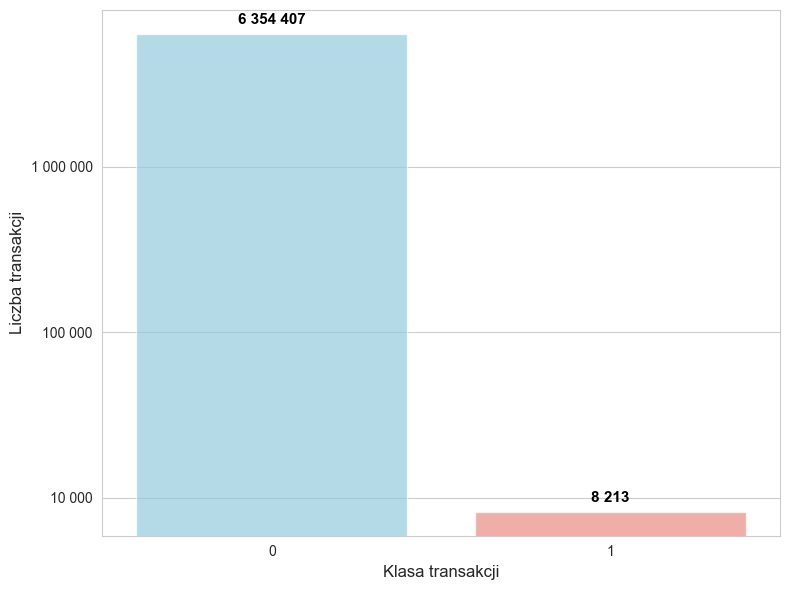

In [10]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=data, 
    x='isFraud', 
    palette=['skyblue', 'salmon'], 
    alpha=0.7
)

plt.xlabel('Klasa transakcji', fontsize=12)
plt.ylabel('Liczba transakcji', fontsize=12)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', ' ')))

for p in ax.patches:
    wysokosc = int(p.get_height())
    ax.annotate(f'{wysokosc:,}'.replace(',', ' '), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, color='black', fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

# skala logarytmiczna:
ax.set_yscale('log')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', ' ')))


plt.tight_layout()
plt.show()

In [11]:
data['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

### Macierz konfuzji dla zmiennych numerycznych

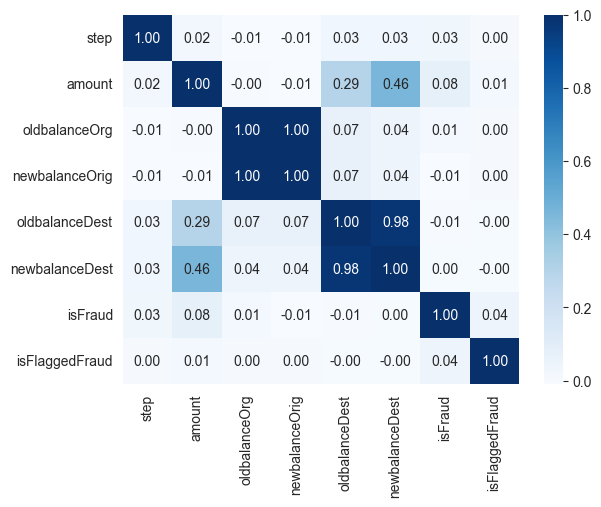

In [12]:
# Liczy korelacje tylko dla kolumn numerycznych
korelacje = data.select_dtypes(include=['number']).corr()

sns.heatmap(korelacje, annot=True, fmt=".2f", cmap='Blues')
plt.show()

Widzimy że zmienna amount jest stosunkowo wysoko skorelowana ze zmiennymi oldbalanceDest i newbalanceDest, co bezpośrednio wynika z definicji zmiennych oldbalanceDest oraz newbalanceDest, gdyz 

**`oldbalanceDest`** + **`amount`** = **`newbalanceDest`** 

Zmienna oldbalanceOrg jest skorelowana na poziomie 1 ze zmienną newBalanceOrg, rowniez zmienna oldbalanceDest jest bardzo wysoko skorelowana ze zmienną newbalanceDest (0.98).

### Rozkład zmiennej amount

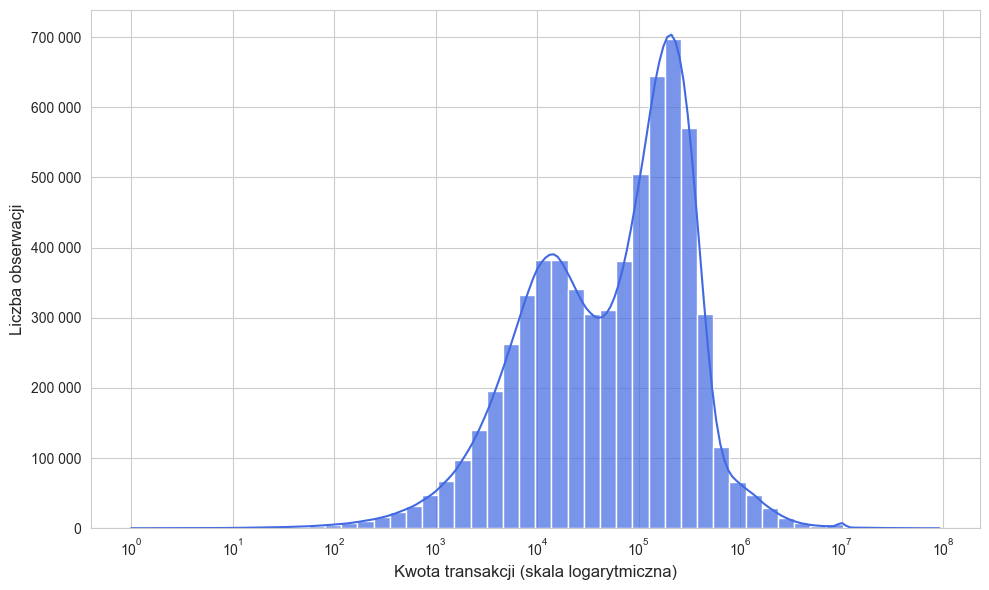

In [13]:
import matplotlib.ticker as ticker

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data['amount'] + 1, 
    bins=50,         
    kde=True, 
    color='royalblue', 
    log_scale=True,
    # edgecolor='white',   
    alpha=0.7
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'.replace(',', ' ')))

# plt.title('Rozkład logarytmiczny kwoty transakcji', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Kwota transakcji (skala logarytmiczna)', fontsize=12)
plt.ylabel('Liczba obserwacji', fontsize=12)

plt.tight_layout()
plt.show()

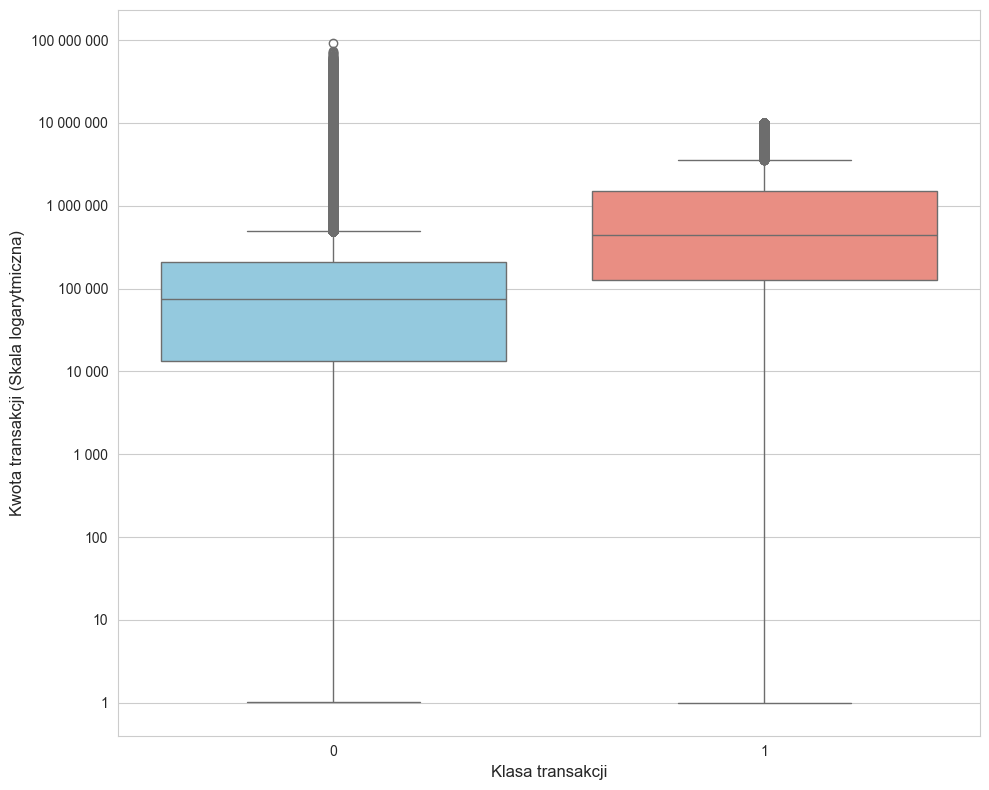

In [14]:
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Dodajemy +1 do kwoty, aby bezpiecznie użyć skali logarytmicznej.
ax = sns.boxplot(
    x='isFraud', 
    y=data['amount'] + 1, 
    data=data, 
    palette=['skyblue', 'salmon']
)

# plt.title('Rozkład kwot transakcji: Prawidłowe vs Oszustwa', fontsize=15, fontweight='bold')
plt.xlabel('Klasa transakcji', fontsize=12)
plt.ylabel('Kwota transakcji (Skala logarytmiczna)', fontsize=12)

# skala logarytmiczną dla osi Y
plt.yscale('log')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', ' ')))

plt.tight_layout()
plt.show()

### Salda nadawcy oraz odbiorcy

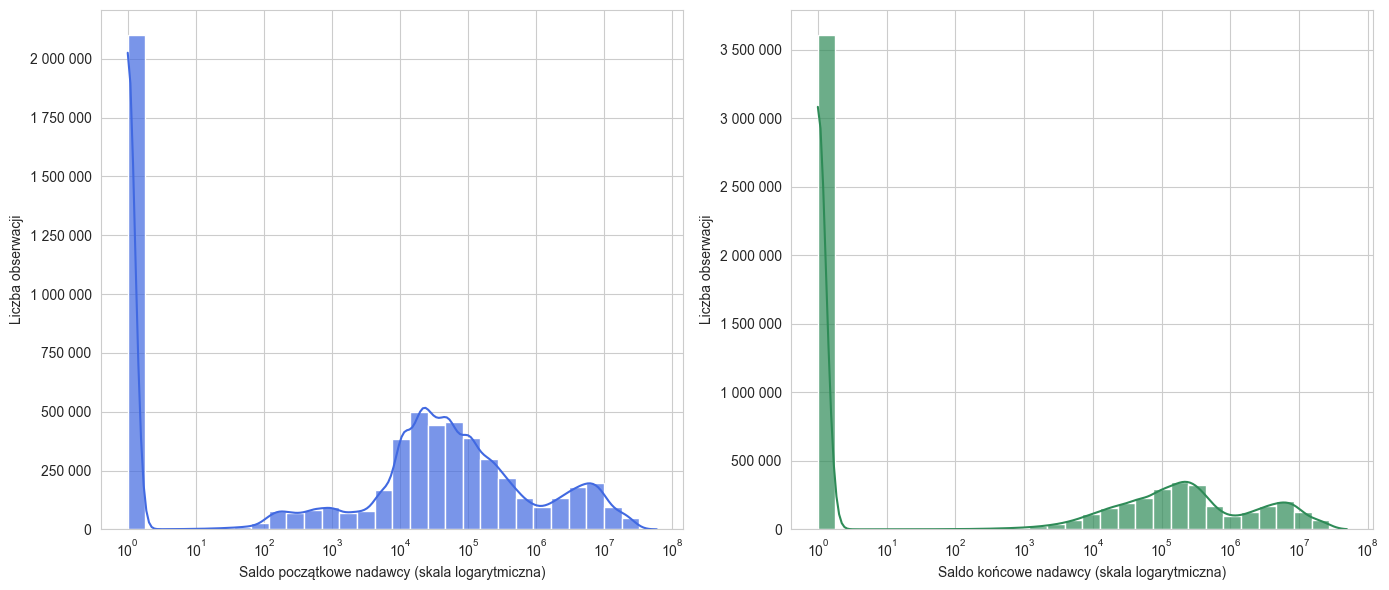

In [15]:
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# oldbalanceOrg 
plt.subplot(1, 2, 1)
ax1 = sns.histplot(data['oldbalanceOrg'] + 1, bins=30, kde=True, color='royalblue', log_scale=True, edgecolor='white', alpha=0.7)
# plt.title('Rozkład salda początkowego nadawcy', fontsize=13, fontweight='bold')
plt.xlabel('Saldo początkowe nadawcy (skala logarytmiczna)')
plt.ylabel('Liczba obserwacji')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'.replace(',', ' ')))

# newbalanceOrig 
plt.subplot(1, 2, 2)
ax2 = sns.histplot(data['newbalanceOrig'] + 1, bins=30, kde=True, color='seagreen', log_scale=True, edgecolor='white', alpha=0.7)
# plt.title('Rozkład salda końcowego nadawcy', fontsize=13, fontweight='bold')
plt.xlabel('Saldo końcowe nadawcy (skala logarytmiczna)')
plt.ylabel('Liczba obserwacji')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'.replace(',', ' ')))

plt.tight_layout()
plt.show()

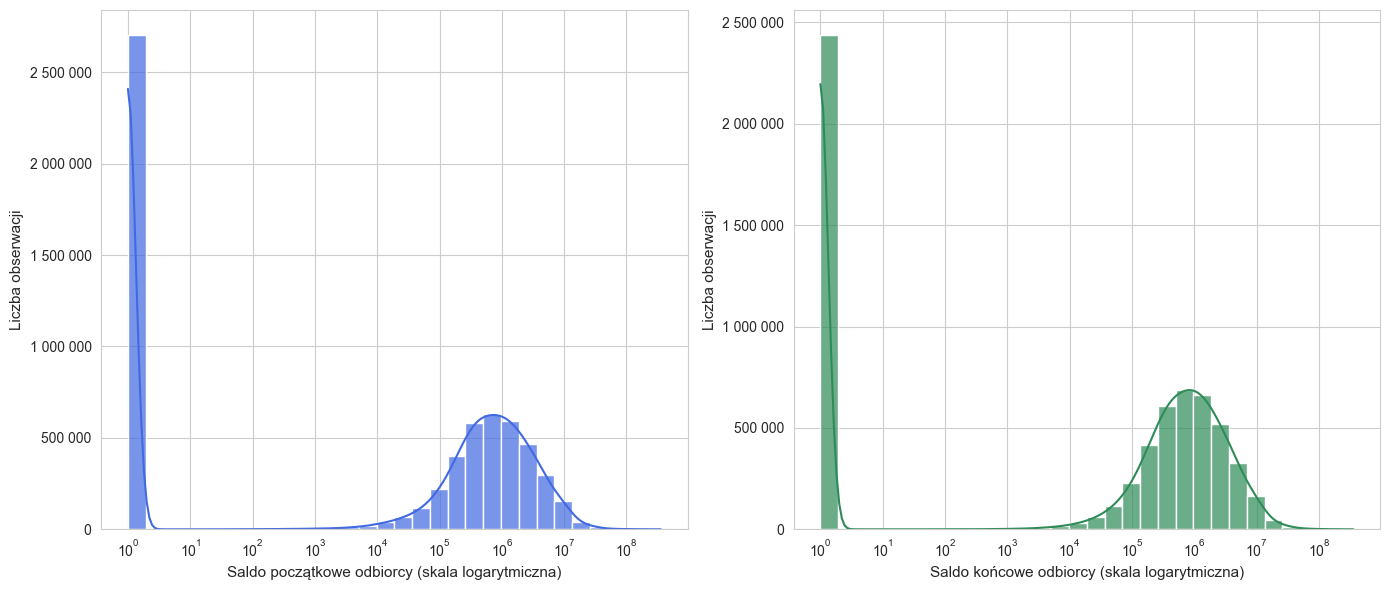

In [16]:
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# oldbalanceDest 
plt.subplot(1, 2, 1)
ax1 = sns.histplot(data['oldbalanceDest'] + 1, bins=30, kde=True, color='royalblue', log_scale=True, edgecolor='white', alpha=0.7)
# plt.title('Rozkład salda początkowego odbiorcy', fontsize=13, fontweight='bold')
plt.xlabel('Saldo początkowe odbiorcy (skala logarytmiczna)', fontsize=11)
plt.ylabel('Liczba obserwacji', fontsize=11)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'.replace(',', ' ')))

# newbalanceDest
plt.subplot(1, 2, 2)
ax2 = sns.histplot(data['newbalanceDest'] + 1, bins=30, kde=True, color='seagreen', log_scale=True, edgecolor='white', alpha=0.7)
# plt.title('Rozkład salda końcowego odbiorcy', fontsize=13, fontweight='bold')
plt.xlabel('Saldo końcowe odbiorcy (skala logarytmiczna)', fontsize=11)
plt.ylabel('Liczba obserwacji', fontsize=11)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'.replace(',', ' ')))

plt.tight_layout()
plt.show()

Widzimy, że istnieje bardzo dużo wystąpień zerowej wartości dla wszystkich czterech zmiennych. 

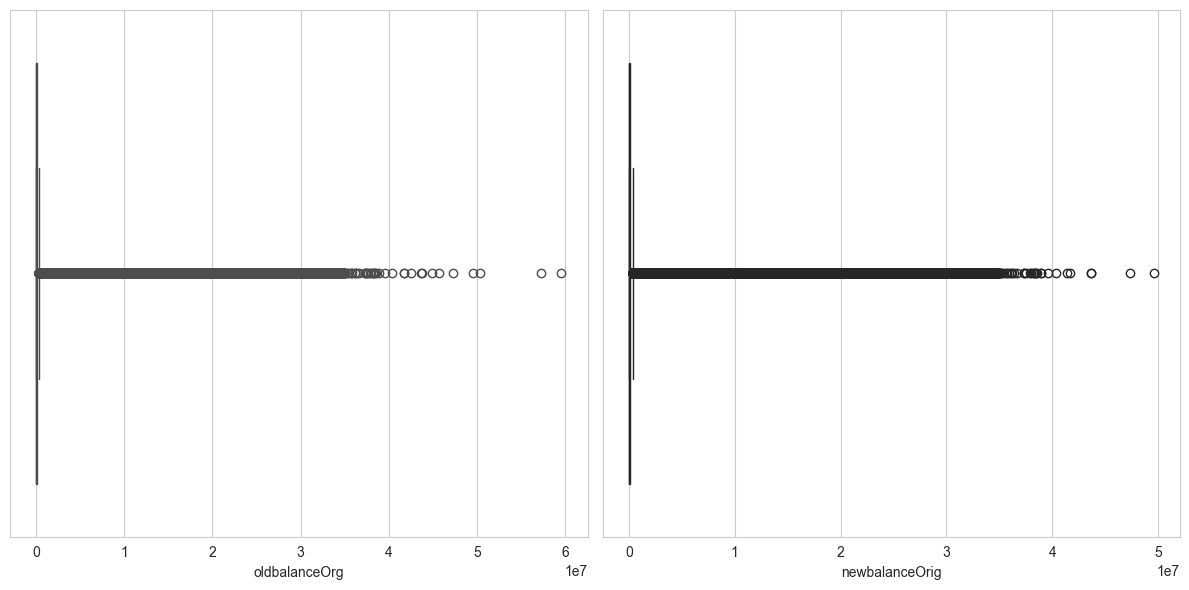

In [17]:
plt.figure(figsize=(12, 6))

# oldbalanceOrg
plt.subplot(1, 2, 1)
sns.boxplot(x=data['oldbalanceOrg'], color='blue')
# plt.title('Boxplot dla coldbalanceOrg')

# newbalanceOrig
plt.subplot(1, 2, 2)
sns.boxplot(x=data['newbalanceOrig'], color='green')
# plt.title('Boxplot dla newbalanceOrig')

plt.tight_layout()
plt.show()

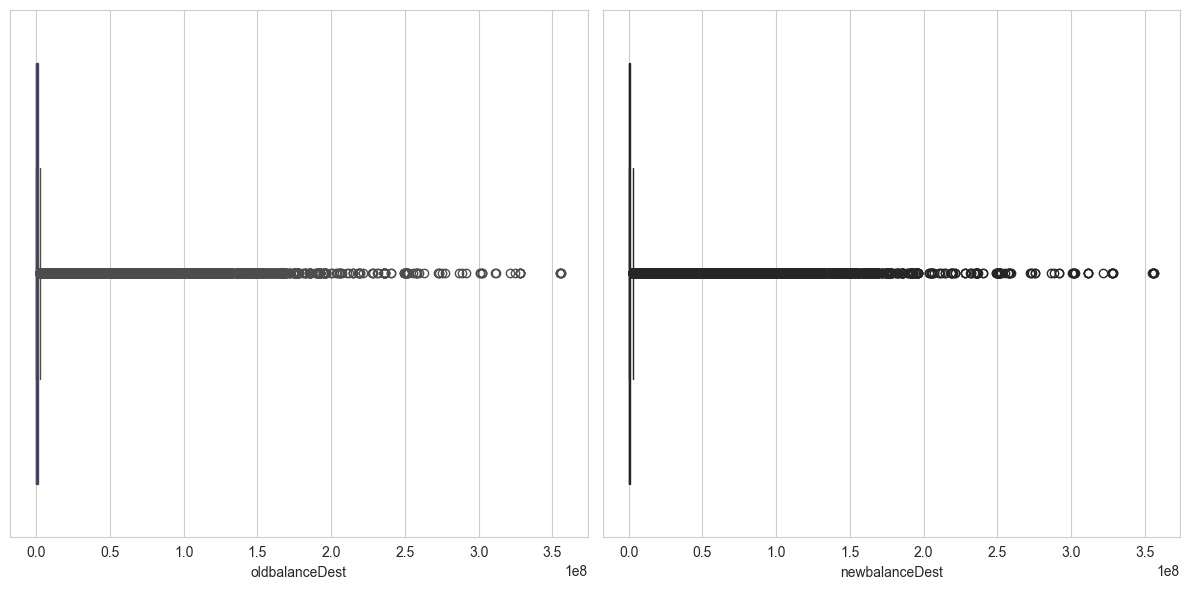

In [18]:
plt.figure(figsize=(12, 6))

# oldbalanceDest
plt.subplot(1, 2, 1)
sns.boxplot(x=data['oldbalanceDest'], color='blue')
# plt.title('Boxplot dla oldbalanceDest')

# newbalanceDest
plt.subplot(1, 2, 2)
sns.boxplot(x=data['newbalanceDest'], color='green')
# plt.title('Boxplot dla newbalanceDest')

plt.tight_layout()
plt.show()

### Wprowadzenie nowych zmiennych

W trakcie analizy eksploracyjnej zidentyfikowano problem niemal idealnej korelacji (na poziomie bliskim 1) pomiędzy bazowymi stanami kont przed i po transakcji (`oldbalance` oraz `newbalance`).  Ponadto, zaobserwowaliśmy, że dla wielu obserwacji salda kont nie pokrywają się z kwotą tranksacji, co oznacza, ze saldo początkowe skorygowane przez kwotę transkacji nie równa się saldu końcowemu, zarówna dla kont nadawcy jak i odbiorcy. 

W związku z powyższym, surowe wartości zastąpiono nowymi zmiennymi:

* **`balanceRatioOrig` oraz `balanceRatioDest`:** Wskaźniki proporcjonalnej zmiany salda. Normalizują one wpływ transakcji na konto, wyrażając go jako ułamek (proporcję) dostępnych środków, zamiast operować na wysoce skośnych wartościach nominalnych. Do mianownika dodano stałą $\epsilon = 0.01$, aby zapobiec błędom dzielenia przez zero w przypadku pustych kont.
* **`errorBalanceOrig` oraz `errorBalanceDest`:** Cechy te mierzą niespójność transakcji (`newbalance + amount - oldbalance`). Równiez inne opracowania zbioru PaySim wskazują, że owe luki w bilansowaniu salda mogą stanowić jeden z predyktorów oszustwa. Z racji tego, iż kwota błędu jest liniowym przekształceniem zmiennych określających balans oraz kwotę transakcji, istnieje ryzyko współliniowości. W związku z tym, w nastęnym kroku dodane zozstaną zmienne binarne określające występowanie błędu **`isErrorOrig`** oraz **`isErrorDest`**.

Wprowadzenie powyższych zmiennych pozwala na bezpieczne odrzucenie zmiennych `newbalanceOrig` oraz `newbalanceDest`.

In [19]:
# Obliczamy błąd salda nadawcy i odbiorcy, pomijając wartości 0
error_orig = data['newbalanceOrig'] + data['amount'] - data['oldbalanceOrg']
error_orig = error_orig[error_orig != 0]

error_dest = data['oldbalanceDest'] + data['amount'] - data['newbalanceDest']
error_dest = error_dest[error_dest != 0]

percentiles = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]
percentile_levels = [p / 100 for p in percentiles]

percentile_orig = error_orig.quantile(percentile_levels).values
percentile_dest = error_dest.quantile(percentile_levels).values

percentile_summary = pd.DataFrame({
    'percentile': percentiles,
    'error_orig': percentile_orig,
    'error_dest': percentile_dest
})

percentile_summary

,percentile,error_orig,error_dest
0,0,-1.000000e-02,-7.588573e+07
1,1,-1.000000e-02,-4.624682e+05
2,5,6.212440e+02,-1.000000e-02
3,10,4.041148e+03,-1.862645e-09
4,25,2.005795e+04,5.595025e+02
5,50,1.248454e+05,1.120471e+04
6,75,2.990451e+05,9.472769e+04
7,90,5.453594e+05,3.618509e+05
8,95,7.701829e+05,5.233366e+05
9,99,1.754706e+06,8.503467e+05


In [20]:
epsilon = 0.01

# Proporcjonalna zmiana na koncie nadawcy
# (Stare saldo - Nowe saldo) / (Stare saldo + mały ułamek)
data['balanceRatioOrig'] = (data['oldbalanceOrg'] - data['newbalanceOrig']) / (data['oldbalanceOrg'] + epsilon)

# Proporcjonalna zmiana na koncie odbiorcy
# (Nowe saldo - Stare saldo) / (Stare saldo + mały ułamek)
data['balanceRatioDest'] = (data['newbalanceDest'] - data['oldbalanceDest']) / (data['oldbalanceDest'] + epsilon)

In [21]:
# Obliczanie różnicy salda dla konta nadawcy
# diffbalanceOrig = newbalanceOrig + amount - oldbalanceOrg
data['errorBalanceOrig'] = data['newbalanceOrig'] + data['amount'] - data['oldbalanceOrg']

# Obliczanie różnicy salda dla konta odbiorcy
# errorBalanceDest = oldbalanceDest + amount - newbalanceDest
data['errorBalanceDest'] = data['oldbalanceDest'] + data['amount'] - data['newbalanceDest']

print(data[['oldbalanceOrg', 'newbalanceOrig', 'amount', 'errorBalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest']].head())

   oldbalanceOrg  newbalanceOrig    amount  errorBalanceOrig  oldbalanceDest  \
0       170136.0       160296.36   9839.64               0.0             0.0   
1        21249.0        19384.72   1864.28               0.0             0.0   
2          181.0            0.00    181.00               0.0             0.0   
3          181.0            0.00    181.00               0.0         21182.0   
4        41554.0        29885.86  11668.14               0.0             0.0   

   newbalanceDest  errorBalanceDest  
0             0.0           9839.64  
1             0.0           1864.28  
2             0.0            181.00  
3             0.0          21363.00  
4             0.0          11668.14  


In [22]:
data.describe().style.format("{:.4f}")

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceRatioOrig,balanceRatioDest,errorBalanceOrig,errorBalanceDest
count,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000,6362620.0000
mean,243.3972,179861.9035,833883.1041,855113.6686,1100701.6665,1224996.3982,0.0013,0.0000,-37082.6818,1960332.6337,201092.4681,55567.1719
std,142.3320,603858.2315,2888242.6730,2924048.5030,3399180.1130,3674128.9421,0.0359,0.0016,997234.3358,26478296.3052,606650.4601,441528.7688
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-81316083.0000,-1.0000,-0.0100,-75885725.6300
25%,156.0000,13389.5700,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2954.2300,0.0000
50%,239.0000,74871.9400,14208.0000,0.0000,132705.6650,214661.4400,0.0000,0.0000,0.0000,0.0000,68677.2550,3500.4900
75%,335.0000,208721.4775,107315.1750,144258.4100,943036.7075,1111909.2500,0.0000,0.0000,0.8359,0.2398,249641.0875,29353.0450
max,743.0000,92445516.6400,59585040.3700,49585040.3700,356015889.3500,356179278.9200,1.0000,1.0000,1.0000,6630841891.0000,92445516.6400,13191233.9800


In [23]:
# próg błędu
tolerancja = 0.01

data['isErrorOrig'] = (data['errorBalanceOrig'].abs() > tolerancja).astype(int)
data['isErrorDest'] = (data['errorBalanceDest'].abs() > tolerancja).astype(int)

print(data[['errorBalanceOrig', 'isErrorOrig', 'errorBalanceDest', 'isErrorDest']].head())

   errorBalanceOrig  isErrorOrig  errorBalanceDest  isErrorDest
0               0.0            0           9839.64            1
1               0.0            0           1864.28            1
2               0.0            0            181.00            1
3               0.0            0          21363.00            1
4               0.0            0          11668.14            1


In [24]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceRatioOrig,balanceRatioDest,errorBalanceOrig,errorBalanceDest,isErrorOrig,isErrorDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.057834,0.0,0.0,9839.64,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.087735,0.0,0.0,1864.28,0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.999945,0.0,0.0,181.00,0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0.999945,-1.0,0.0,21363.00,0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.280795,0.0,0.0,11668.14,0,1


In [25]:
data['isErrorDest'].value_counts()

isErrorDest
1    4188647
0    2173973
Name: count, dtype: int64

In [26]:
data['isErrorOrig'].value_counts()

isErrorOrig
1    5081184
0    1281436
Name: count, dtype: int64

In [27]:
# Usuwamy początkowe kolumny z saldami
data_clean = data.drop(columns=[
    'oldbalanceOrg',
    'oldbalanceDest',
    'newbalanceOrig', 
    'newbalanceDest',
    'errorBalanceOrig',
    'errorBalanceDest'
])

data_clean.head()

,step,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,balanceRatioOrig,balanceRatioDest,isErrorOrig,isErrorDest
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0,0,0.057834,0.0,0,1
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0,0,0.087735,0.0,0,1
2,1,TRANSFER,181.00,C1305486145,C553264065,1,0,0.999945,0.0,0,1
3,1,CASH_OUT,181.00,C840083671,C38997010,1,0,0.999945,-1.0,0,1
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0,0,0.280795,0.0,0,1


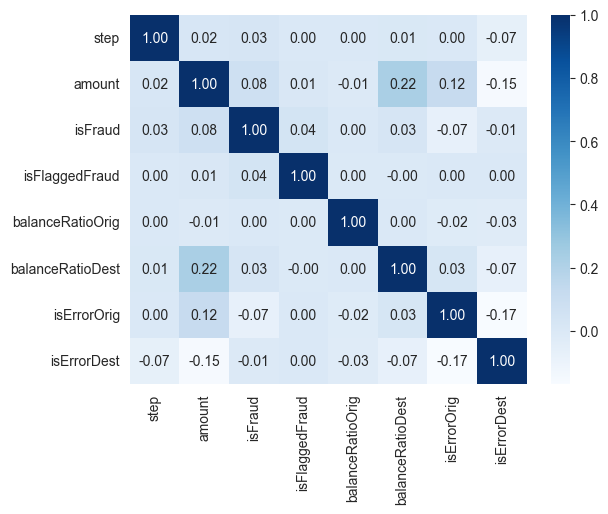

In [28]:
korelacje = data_clean.select_dtypes(include=['number']).corr()

sns.heatmap(korelacje, annot=True, fmt=".2f", cmap='Blues')
plt.show()

Udało się uzyskać mniejsze wartości korelacji między zmiennymi


### Rozkład oszustw dla poszczególnych typów transakcji

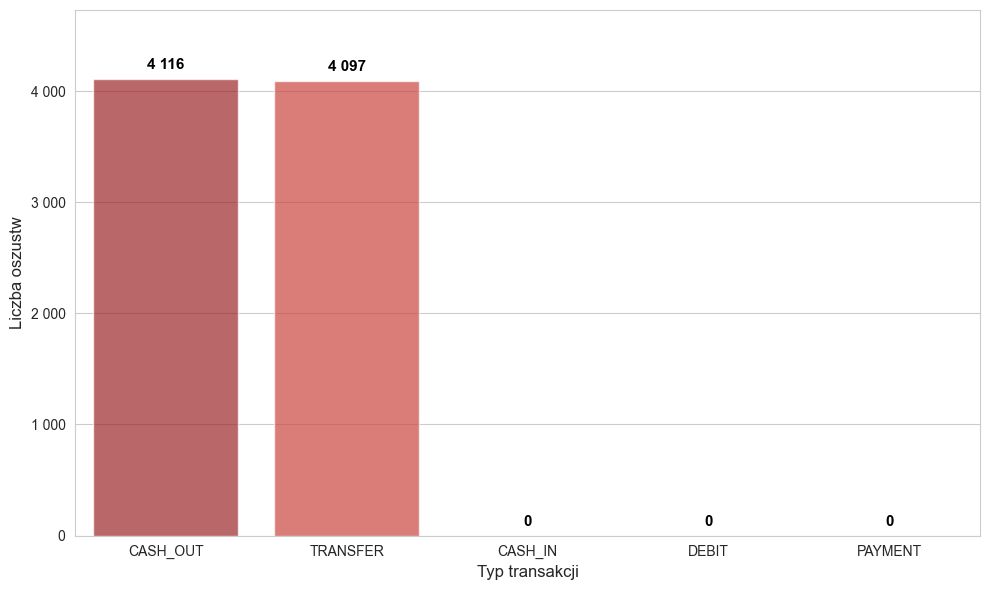

In [29]:
fraud_counts = data_clean.groupby('type')['isFraud'].sum().reset_index()
fraud_counts = fraud_counts.sort_values(by='isFraud', ascending=False)

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=fraud_counts, 
    x='type', 
    y='isFraud', 
    palette='Reds_r', 
    alpha=0.7
)

#plt.title('Rozkład oszustw dla poszczególnych typów transakcji', fontsize=15, fontweight='bold')
plt.xlabel('Typ transakcji', fontsize=12)
plt.ylabel('Liczba oszustw', fontsize=12)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', ' ')))

for p in ax.patches:
    wysokosc = int(p.get_height())
    ax.annotate(f'{wysokosc:,}'.replace(',', ' '), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, color='black', fontweight='bold',
                xytext=(0, 5), textcoords='offset points')


plt.ylim(0, fraud_counts['isFraud'].max() * 1.15)

# ax.set_yscale('log')

plt.tight_layout()
plt.show()

### Analiza czasu transakcji
Zmienna `step` (reprezentująca kolejne godziny symulacji od 1 do 744) została poddana transformacji przy użyciu operacji modulo 24 (`step % 24`). Dzięki temu uzyskano nową cechę `hour`, odzwierciedlającą dokładną godzinę w cyklu dobowym (od 0 do 23). 

Wizualizacja gęstości rozkładu (zawarta ponizej) ujawniła kluczową anomalię w zbiorze PaySim:
1. **Transakcje prawidłowe:** Wykazują naturalny, "ludzki" cykl dobowy. Aktywność finansowa zamiera w godzinach nocnych (0:00 - 6:00), po czym rośnie, osiągając szczyt w godzinach popołudniowych.
2. **Oszustwa:** Wykazują rozkład jednostajny. Oszuści w systemie PaySim wykonują podejrzane operacje (CASH_OUT, TRANSFER) z niemal identyczną częstotliwością o każdej porze dnia i nocy.

Transakcja wykonana w środku nocy ma znacznie wyższe prawdopodobieństwo bycia oszustwem niż analogiczna transakcja w środku dnia. Wprowadzenie zmiennej `hour` będzie dostarczało istotnej informacji do separacji klas, która była całkowicie ukryta w surowej zmiennej `step`.

In [30]:
# Wyliczamy godzinę z cyklu dobowego
data_clean['hour'] = data_clean['step'] % 24

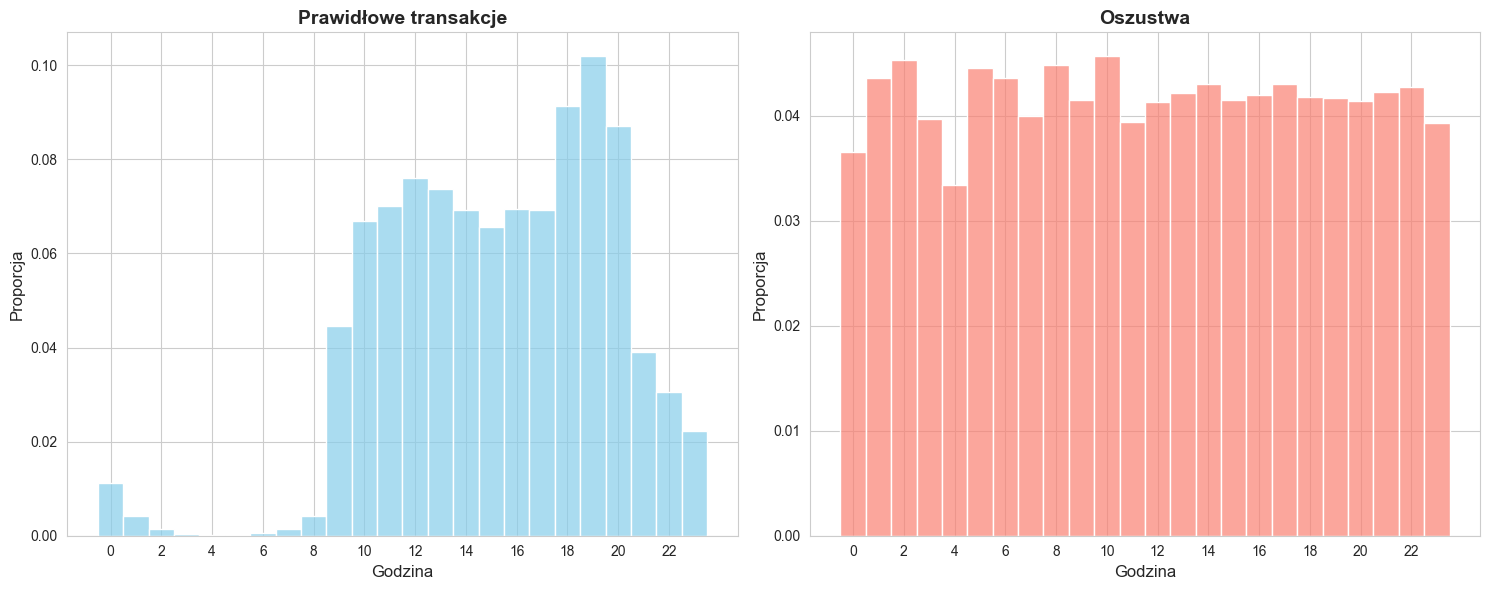

In [31]:
fraudy = data_clean[data_clean['isFraud'] == 1]
prawidlowe = data_clean[data_clean['isFraud'] == 0]

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Wykres 1: Prawidłowe transakcje
sns.histplot(
    prawidlowe['hour'],
    bins=24,
    ax=axes[0],
    stat='density',
    color='skyblue',
    discrete=True,
    alpha=0.7
)
axes[0].set_title('Prawidłowe transakcje', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Godzina', fontsize=12)
axes[0].set_ylabel('Proporcja', fontsize=12)
axes[0].set_xticks(range(0, 24, 2))

# Wykres 2: Oszustwa
sns.histplot(
    fraudy['hour'],
    bins=24,
    ax=axes[1],
    color='salmon',
    stat='density',
    discrete=True,
    alpha=0.7 
)
axes[1].set_title('Oszustwa', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Godzina', fontsize=12)
axes[1].set_ylabel('Proporcja', fontsize=12)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

In [32]:
data_clean.groupby('isFraud')['amount'].median()

isFraud
0     74684.72
1    441423.44
Name: amount, dtype: float64

In [33]:
data_clean.head()

,step,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,balanceRatioOrig,balanceRatioDest,isErrorOrig,isErrorDest,hour
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0,0,0.057834,0.0,0,1,1
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0,0,0.087735,0.0,0,1,1
2,1,TRANSFER,181.00,C1305486145,C553264065,1,0,0.999945,0.0,0,1,1
3,1,CASH_OUT,181.00,C840083671,C38997010,1,0,0.999945,-1.0,0,1,1
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0,0,0.280795,0.0,0,1,1


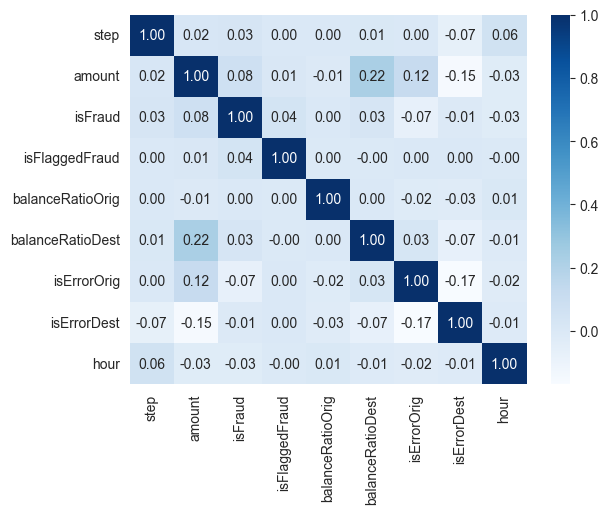

In [34]:
korelacje = data_clean.select_dtypes(include=['number']).corr()

sns.heatmap(korelacje, annot=True, fmt=".2f", cmap='Blues')
plt.show()

- Usuwamy zmienne `nameOrig` oraz `nameDest` ponieważ jako zmienne kategoryczne dałyby nam setki tysięcy zmiennych binarnych oraz same w sobie nie niosą wiele informacji. 
- Usuwamy również zmienną `isFlaggedFraud` ponieważ jest to automatyczne oznaczanie każdej transakcji, której kwota jest większa od 200 000, a więc jest to reguła biznesowa (subiektywna) niekoniecznie przydatna jako predyktor modelu uczącego się na samych danych. 
- Usuwamy również zmienną `step`, poniewaz została zastąpiona zmienną `hour`. 

In [35]:
data_clean = data_clean.drop(columns=[
    'nameOrig',
    'nameDest',
    'isFlaggedFraud',
    'step'
])

In [36]:
data_clean.head()

,type,amount,isFraud,balanceRatioOrig,balanceRatioDest,isErrorOrig,isErrorDest,hour
0,PAYMENT,9839.64,0,0.057834,0.0,0,1,1
1,PAYMENT,1864.28,0,0.087735,0.0,0,1,1
2,TRANSFER,181.00,1,0.999945,0.0,0,1,1
3,CASH_OUT,181.00,1,0.999945,-1.0,0,1,1
4,PAYMENT,11668.14,0,0.280795,0.0,0,1,1


### Zapisanie gotowych danych

W tej części dzielimy gotowy zbiór na dane testowe i treningowe oraz zapisujemy lokalnie, tak aby użyć ich do budowania modelu.

In [37]:
data_clean['type'] = data_clean['type'].astype('category')

X = data_clean.drop('isFraud', axis=1)
y = data_clean['isFraud']

# Podział na zbiór testowy i treningowy 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

os.makedirs('gotowe_dane', exist_ok=True) 

# aby zapisać dane lokalnie należy odkomentować poniższe linie kodu

# X_train.to_parquet('gotowe_dane/X_train.parquet')
# X_test.to_parquet('gotowe_dane/X_test.parquet')
# y_train.to_frame().to_parquet('gotowe_dane/y_train.parquet')
# y_test.to_frame().to_parquet('gotowe_dane/y_test.parquet')